
📂 분석 시작: 파일명 ➤ **250602-IF-ATSC/clean.xlsx**


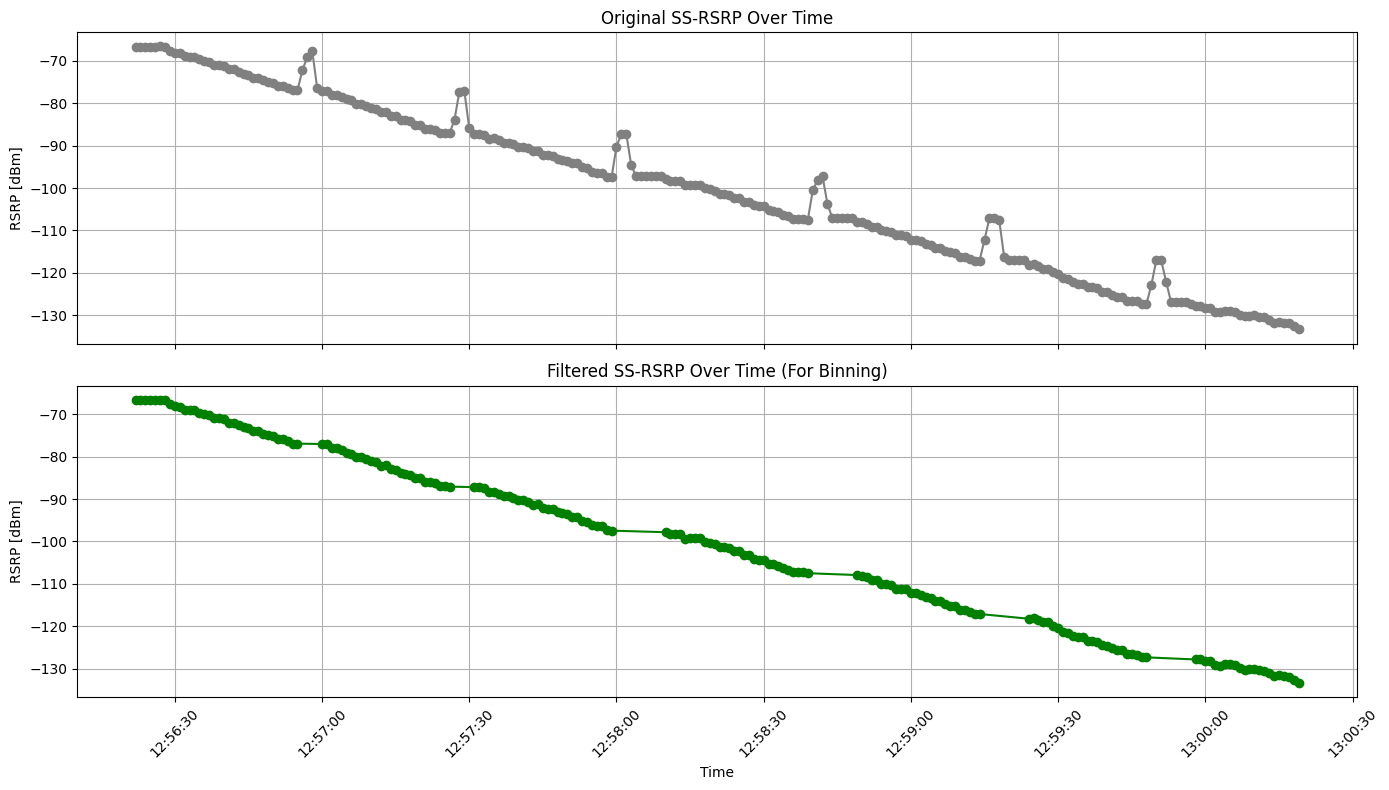


✅ Basic Info:


,RF Serving PCI,Chip Type,RF Serving PCI MOD 3,RF Serving PCI MOD 4,RF NR-ARFCN,RF Frequency [MHz],RF Subcarrier Spacing,RF Tx Beam ID 0,RF Serving PCI-SSB Idx,RF Serving SSB Idx,RF RI3 Rate [%],RF RI4 Rate [%],RF CRI,Layer1 UL Modulation UL Pi/2 BPSK Rate [%]
0,1.0,5G-NR Qualcomm,1.0,1.0,158450.0,792.25,15kHz,3.0,1_3,3.0,0.0,0.0,0.0,0.0



📌 RSRP 1dB Binning:


,RSRP_Bin,RF Serving PCI,RF Serving PCI MOD 3,RF Serving PCI MOD 4,RF NR-ARFCN,RF Frequency [MHz],RF Tx Beam ID 0,RF Serving SSB Idx,RF Serving SS-RSRP [dBm],RF Serving SS-RSRQ [dB],...,Layer1 DL Modulation0 DL 256 QAM Rate [%],Layer1 UL Modulation UL Pi/2 BPSK Rate [%],Layer1 UL Modulation UL QPSK Rate [%],Layer1 UL Modulation UL 16QAM Rate [%],Layer1 UL Modulation UL 64QAM Rate [%],Layer1 UL Modulation UL 256 QAM Rate [%],Layer2 MAC DL Throughput [Mbps],Layer2 MAC UL Throughput [Mbps],RSRP_Break_Flag,Filter
0,-66 ~ -67,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-66.641429,-10.327143,...,100.0,0.0,0.0,0.0,0.0,100.0,208.729429,1.094000,0.0,1.0
1,-67 ~ -68,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-67.670000,-10.330000,...,100.0,0.0,0.0,0.0,0.0,100.0,208.721000,1.023000,0.0,1.0
2,-68 ~ -69,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-68.436667,-10.330000,...,100.0,0.0,0.0,0.0,0.0,100.0,207.677000,1.066667,0.0,1.0
3,-69 ~ -70,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-69.402500,-10.322500,...,100.0,0.0,0.0,0.0,0.0,100.0,208.393000,1.044250,0.0,1.0
4,-70 ~ -71,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-70.733333,-10.326667,...,100.0,0.0,0.0,0.0,0.0,100.0,207.552000,0.979333,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,-129 ~ -130,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-129.306000,-16.134000,...,0.0,0.0,100.0,0.0,0.0,0.0,3.391600,0.042800,0.0,1.0
64,-130 ~ -131,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-130.256000,-16.644000,...,0.0,0.0,100.0,0.0,0.0,0.0,2.753200,0.028400,0.0,1.0
65,-131 ~ -132,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-131.598000,-17.590000,...,0.0,0.0,100.0,0.0,0.0,0.0,0.267400,0.033400,0.0,1.0
66,-132 ~ -133,1.0,1.0,1.0,158450.0,792.25,3.0,3.0,-132.560000,-18.280000,...,0.0,0.0,100.0,0.0,0.0,0.0,0.043000,0.030000,0.0,1.0


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_kpi_by_rsrp_bin(file_path, custom_bin_size=5, print_on=False):
    if print_on: print(f"\n📂 분석 시작: 파일명 ➤ **{file_path}**")

    # ============================
    # 1. 데이터 로드 및 KPI 컬럼 정리
    # ============================
    df_raw = pd.read_excel(file_path, sheet_name="Sheet1")
    df_initial_cut = df_raw.filter(regex="^(TIME_STAMP|5G KPI PCell )")
    df_initial_cut.columns = [
        col if col == "TIME_STAMP" else col.replace("5G KPI PCell ", "")
        for col in df_initial_cut.columns
    ]

    # ======================================
    # 2. 시험망 PCI=1만 필터링
    # ======================================
    df_initial_cut = df_initial_cut[df_initial_cut["RF Serving PCI"] == 1].reset_index(drop=True)
    df_initial_cut = df_initial_cut[df_initial_cut["RF Band"] != "n78"].reset_index(drop=True)
    df_main_kpi_only = df_initial_cut.copy()

    # ======================================
    # 3. RSRP 급변 감지 및 필터 생성
    # ======================================
    df_main_kpi_only = df_main_kpi_only.sort_values(by="TIME_STAMP").reset_index(drop=True)
    diff_rsrp = df_main_kpi_only["RF Serving SS-RSRP [dBm]"].diff().fillna(0)
    df_main_kpi_only["RSRP_Break_Flag"] = diff_rsrp > 1

    filter_flags = []
    current_state = True
    last_valid_rsrp = df_main_kpi_only["RF Serving SS-RSRP [dBm]"].iloc[0]

    for _, row in df_main_kpi_only.iterrows():
        rsrp = row["RF Serving SS-RSRP [dBm]"]
        is_break = row["RSRP_Break_Flag"]

        if is_break:
            current_state = False
        if not current_state and rsrp < last_valid_rsrp:
            current_state = True
        if current_state:
            last_valid_rsrp = rsrp

        filter_flags.append(current_state)

    df_main_kpi_only["Filter"] = filter_flags

    # ======================================
    # 4. 필터 적용 + NaN-only 컬럼 제거
    # ======================================
    df_filtered_rsrp = df_main_kpi_only[df_main_kpi_only["Filter"] == True].reset_index(drop=True)
    df_rsrp_for_binning = df_filtered_rsrp.sort_values(by="TIME_STAMP").dropna(axis=1, how="all").reset_index(drop=True)
    # df_rsrp_for_binning = df_rsrp_for_binning.iloc[:-2]  # 마지막 2개 행 제거

    # ======================================
    # 5. 시각화: 원본 vs 필터링된 RSRP
    # ======================================
    if print_on:
        fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
        axs[0].plot(
            df_main_kpi_only["TIME_STAMP"],
            df_main_kpi_only["RF Serving SS-RSRP [dBm]"],
            label="Original",
            color="gray",
            marker="o"
        )
        axs[0].set_title("Original SS-RSRP Over Time")
        axs[0].set_ylabel("RSRP [dBm]")
        axs[0].grid(True)
    
        axs[1].plot(
            df_rsrp_for_binning["TIME_STAMP"],
            df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"],
            label="Filtered for Binning",
            color="green",
            marker="o"
        )
        axs[1].set_title("Filtered SS-RSRP Over Time (For Binning)")
        axs[1].set_xlabel("Time")
        axs[1].set_ylabel("RSRP [dBm]")
        axs[1].grid(True)
    
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ======================================
    # 6. 고정값 (Info) 추출
    # ======================================
    repeated_cols = [col for col in df_initial_cut.columns if df_initial_cut[col].nunique(dropna=True) == 1]
    df_static_info = df_initial_cut[repeated_cols].iloc[:1].copy()
    if print_on: 
        print("\n✅ Basic Info:")
        display(df_static_info)
    
    # ======================================
    # 7. RSRP 1dB → 5dB 구간 Binning 및 Pivot Table 생성
    # ======================================

    # ✅ 1단계: 1dB 단위 Binning
    min_rsrp = int(df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"].min())
    max_rsrp = int(df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"].max())

    bin_edges_1dB = list(range(min_rsrp - 1, max_rsrp + 2))
    labels_1dB = [f"{bin_edges_1dB[i+1]} ~ {bin_edges_1dB[i]}" for i in range(len(bin_edges_1dB) - 1)]

    df_rsrp_for_binning["RSRP_Bin_1dB"] = pd.cut(
        df_rsrp_for_binning["RF Serving SS-RSRP [dBm]"],
        bins=bin_edges_1dB,
        labels=labels_1dB,
        right=True,
        include_lowest=True
    )

    pivot_1dB = (
        df_rsrp_for_binning
        .groupby("RSRP_Bin_1dB", observed=True)
        .mean(numeric_only=True)
        .reset_index()
        .sort_values(by="RSRP_Bin_1dB", ascending=False)
    )
    pivot_1dB = pivot_1dB.reset_index(drop=True)

    # ✅ 마지막 N개 구간 이상치 검사
    tail_check_range = 5  # 예: 마지막 5개 bin
    spike_thresh = 10     # 예: 10Mbps 이상 튐이면 이상치
    keep_flags = [True] * len(pivot_1dB)
    for i in range(len(pivot_1dB) - tail_check_range, len(pivot_1dB)):
        if i == 0:
            continue  # 첫 구간은 비교 불가
        prev = pivot_1dB.loc[i-1, "Layer1 PDSCH Throughput [Mbps]"]
        curr = pivot_1dB.loc[i, "Layer1 PDSCH Throughput [Mbps]"]
        if curr - prev > spike_thresh:
            keep_flags[i] = False  # 이상치로 제거
    pivot_1dB = pivot_1dB[keep_flags].reset_index(drop=True)
    
    # if print_on: 
    #     print("\n📌 RSRP 1dB Binning:")
    #     display(pivot_1dB)


    # ✅ 사용자 정의 bin size로 재binning
    bin_floor = int((min_rsrp // custom_bin_size - 1) * custom_bin_size)
    bin_ceil = int((max_rsrp // custom_bin_size + 2) * custom_bin_size)
    bin_edges_custom = list(range(bin_floor, bin_ceil + 1, custom_bin_size))
    labels_custom = [f"{bin_edges_custom[i+1]} ~ {bin_edges_custom[i]}" for i in range(len(bin_edges_custom) - 1)]
    pivot_1dB["RSRP_Bin"] = pd.cut(
        pivot_1dB["RF Serving SS-RSRP [dBm]"],
        bins=bin_edges_custom,
        labels=labels_custom,
        right=True,
        include_lowest=True
    )
    numeric_cols = pivot_1dB.select_dtypes(include="number").columns
    pivot_custom = (
        pivot_1dB
        .groupby("RSRP_Bin", observed=True)[numeric_cols]
        .mean()
        .reset_index()
        .sort_values(by="RSRP_Bin", ascending=False)
    )
    pivot_custom = pivot_custom.reset_index(drop=True)

    if print_on:
        print(f"\n📌 RSRP {custom_bin_size}dB Binning:")
        display(pivot_custom)

    return pivot_custom

pivot =analyze_kpi_by_rsrp_bin("250602-IF-ATSC/clean.xlsx", custom_bin_size=1, print_on=True)
    
#     # ✅ 2단계: 5의 배수로 딱 맞춰지는 bin 경계값 생성
#     bin_floor = int((min_rsrp // 5 - 1) * 5)       # 예: -131이면 → -135
#     bin_ceil  = int((max_rsrp // 5 + 2) * 5)       # 예: -64이면  → -60
    
#     bin_edges_5dB = list(range(bin_floor, bin_ceil + 1, 5))
#     labels_5dB = [f"{bin_edges_5dB[i+1]} ~ {bin_edges_5dB[i]}" for i in range(len(bin_edges_5dB) - 1)]

#     pivot_1dB["RSRP_Bin_5dB"] = pd.cut(
#         pivot_1dB["RF Serving SS-RSRP [dBm]"],
#         bins=bin_edges_5dB,
#         labels=labels_5dB,
#         right=True,
#         include_lowest=True
#     )

#     numeric_cols = pivot_1dB.select_dtypes(include="number").columns
#     pivot_5dB = (
#         pivot_1dB
#         .groupby("RSRP_Bin_5dB", observed=True)[numeric_cols]
#         .mean()
#         .reset_index()
#         .sort_values(by="RSRP_Bin_5dB", ascending=False)
#     )

#     pivot_5dB = pivot_5dB.reset_index(drop=True)
    
#     if print_on: 
#         print("\n📊 RSRP 5dB Binning:")
#         display(pivot_5dB)

#     return pivot_1dB, pivot_5dB

# pivot_1dB, pivot_5dB =analyze_kpi_by_rsrp_bin("250602-IF-ATSC/clean.xlsx", print_on=True)

In [2]:
pivot =analyze_kpi_by_rsrp_bin("250602-IF-ATSC/clean.xlsx", custom_bin_size=1, print_on=False)
display(pivot.iloc[-2:][['RSRP_Bin','Layer1 DL MCS (Avg)','Layer1 PDSCH Throughput [Mbps]']])

,RSRP_Bin,Layer1 DL MCS (Avg),Layer1 PDSCH Throughput [Mbps]
66,-132 ~ -133,0.0,0.065
67,-133 ~ -134,0.0,0.043


In [3]:
### TEST ####
def search_kpi_with_keyword(df):
    kpi_keywords = ["rsrp", "mcs", "rb", "ri2", "bler", "pdsch throughput",'cqi','sinr']
    kpi_candidate_columns = [
        col for col in df.columns
        if any(keyword in col.lower() for keyword in kpi_keywords)
        and "ul" not in col.lower()
        and 'flag' not in col.lower()
        and 'mac' not in col.lower()
        and 'pusch' not in col.lower()
    ]
    final_kpi_columns = [
        col for col in kpi_candidate_columns
        if "(mode)" not in col.lower()
        and "(including 0)" not in col.lower()
    ]    
    display(df[final_kpi_columns].reset_index(drop=True))

search_kpi_with_keyword(pivot)

,RSRP_Bin,RF Serving SS-RSRP [dBm],RF Serving SS-SINR [dB],RF RI2 Rate [%],RF CQI,Layer1 DL BLER [%],Layer1 DL MCS (Avg),Layer1 DL RB Num (Avg),Layer1 PDSCH Throughput [Mbps]
0,-66 ~ -67,-66.641429,40.901429,100.0,15.000,5.868571,26.157143,104.100000,221.980857
1,-67 ~ -68,-67.670000,41.000000,100.0,15.000,5.400000,26.160000,104.060000,220.798000
2,-68 ~ -69,-68.436667,40.900000,100.0,15.000,6.556667,26.173333,104.090000,222.384000
3,-69 ~ -70,-69.402500,41.000000,100.0,15.000,6.060000,26.165000,104.085000,222.102500
4,-70 ~ -71,-70.733333,40.586667,100.0,15.000,6.420000,26.156667,104.083333,221.961667
...,...,...,...,...,...,...,...,...,...
63,-129 ~ -130,-129.306000,-4.054000,0.0,3.206,1.086000,0.194000,104.282000,3.440400
64,-130 ~ -131,-130.256000,-4.938000,0.0,3.040,11.022000,0.000000,104.324000,3.128000
65,-131 ~ -132,-131.598000,-5.936000,0.0,2.848,20.770000,0.042000,63.582000,0.295200
66,-132 ~ -133,-132.560000,-6.290000,0.0,3.170,33.330000,0.000000,71.410000,0.065000


In [4]:
def filter_and_rename_kpi(df):
    
    # ✅ 기본 KPI 매핑 정의
    rename_dict = {
        "RSRP_Bin": "NR_RSRP[dBm]",
        "RF RI2 Rate [%]": "RI2_Rate[%]",
        "Layer1 DL BLER [%]": "DL_BLER[%]",
        "Layer1 DL MCS (Avg)": "DL_MCS",
        "Layer1 DL RB Num (Avg)": "DL_RB_Num",
        "Layer1 PDSCH Throughput [Mbps]": "DL_Tput[Mbps]",
        "RF CQI": "CQI",
        "RF Serving SS-SINR [dB]": "SINR[dB]",
    }

    # ✅ 실제 존재하는 컬럼 중 rename_dict 기준으로 필터링
    columns_to_display = [col for col in rename_dict if col in df.columns]

    # ✅ 출력용 테이블 생성 및 컬럼명 변경
    df_renamed = df[columns_to_display].rename(columns=rename_dict)
    df_renamed = df_renamed.reset_index(drop=True)

    # ✅ 칼럼 순서 지정 (존재하지 않는 항목은 자동 제거)
    final_columns = ['NR_RSRP[dBm]', 'DL_Tput[Mbps]', 'DL_MCS', 'DL_BLER[%]', 'SINR[dB]', "CQI", 'RI2_Rate[%]', 'DL_RB_Num']
    final_columns = [col for col in final_columns if col in df_renamed.columns]
    df_renamed = df_renamed[final_columns]

    return df_renamed
    
filter_and_rename_kpi(pivot)

,NR_RSRP[dBm],DL_Tput[Mbps],DL_MCS,DL_BLER[%],SINR[dB],CQI,RI2_Rate[%],DL_RB_Num
0,-66 ~ -67,221.980857,26.157143,5.868571,40.901429,15.000,100.0,104.100000
1,-67 ~ -68,220.798000,26.160000,5.400000,41.000000,15.000,100.0,104.060000
2,-68 ~ -69,222.384000,26.173333,6.556667,40.900000,15.000,100.0,104.090000
3,-69 ~ -70,222.102500,26.165000,6.060000,41.000000,15.000,100.0,104.085000
4,-70 ~ -71,221.961667,26.156667,6.420000,40.586667,15.000,100.0,104.083333
...,...,...,...,...,...,...,...,...
63,-129 ~ -130,3.440400,0.194000,1.086000,-4.054000,3.206,0.0,104.282000
64,-130 ~ -131,3.128000,0.000000,11.022000,-4.938000,3.040,0.0,104.324000
65,-131 ~ -132,0.295200,0.042000,20.770000,-5.936000,2.848,0.0,63.582000
66,-132 ~ -133,0.065000,0.000000,33.330000,-6.290000,3.170,0.0,71.410000


In [5]:
import os
import pandas as pd

def concat_kpi(test_dir, bin_size=5):

    directory_path = os.getcwd()
    input_path = os.path.join(directory_path, test_dir)
    # print(input_path)
    
    excel_files = [
        f for f in os.listdir(input_path)
        if f.endswith(".xlsx") and 
        '$' not in f and
        "rsrp_bin" not in f
    ]

    clean = [f.replace('.xlsx', '') for f in excel_files if "clean" in f]
    others = [f.replace('.xlsx', '') for f in excel_files if "clean" not in f]
    others_sorted = sorted(others, key=lambda x: int(x.replace('dBm', '')), reverse=False)
    sources = clean + others_sorted
    source_order = {src: idx for idx, src in enumerate(sources)}

    # print(source_order)
    
    # ✅ 처리 결과 누적 저장
    dfs = []
    for filename in excel_files:
        file_path = os.path.join(input_path, filename)
        file_tag = os.path.splitext(filename)[0]
        try:
            pivot = analyze_kpi_by_rsrp_bin(file_path, custom_bin_size= bin_size, print_on=False)
            df = filter_and_rename_kpi(pivot)
            df["IF_Power"] = file_tag
            dfs.append(df)
            
        except Exception as e:
            print(f"❌ 처리 실패: {filename} → {e}")
    
    df_stacked = pd.concat(dfs, ignore_index=True)
    df_stacked = df_stacked.reset_index(drop=True)
    
    # 1. RSRP_Bin: 정수 기준 첫 값 추출 (예: "-65 ~ -60" → -65)
    df_stacked["RSRP_Bin_SortKey"] = df_stacked["NR_RSRP[dBm]"].str.extract(r"(-?\d+)").astype(int)
    
    # 2. Source 우선순위 명시 (NoPower → -50dBm → ...)
    # print(source_order)
    df_stacked["Source_SortKey"] = df_stacked["IF_Power"].map(source_order).fillna(99)
    
    # 3. 정렬 수행
    df_stacked = df_stacked.sort_values(
        by=["RSRP_Bin_SortKey", "Source_SortKey"],
        ascending=[False, True]
    )
    
    # 4. 정렬 키 제거 후 MultiIndex 재설정
    df_stacked = df_stacked.drop(columns=["RSRP_Bin_SortKey", "Source_SortKey"])
    df_stacked = df_stacked.set_index(["NR_RSRP[dBm]", "IF_Power"])

    output_path = os.path.join(test_dir, f"kpi_tables_rsrp_bin_{bin_size}dB.xlsx")
    df_stacked.to_excel(output_path, index=True, float_format="%.2f")
    
    return df_stacked, source_order

df_stacked, source_order = concat_kpi(test_dir = "250602-IF-ATSC", bin_size=1)
display(df_stacked)

DL_Tput[Mbps]     DL_MCS  DL_BLER[%]   SINR[dB]  \
NR_RSRP[dBm] IF_Power                                                    
-66 ~ -67    clean        221.980857  26.157143    5.868571  40.901429   
             -46dBm       222.891600  26.168000    3.814000  40.550000   
             -41dBm       222.168125  26.166250    3.812500  40.617500   
             -21dBm       222.168714  26.158571    7.061429  41.095714   
-67 ~ -68    clean        220.798000  26.160000    5.400000  41.000000   
...                              ...        ...         ...        ...   
-132 ~ -133  -41dBm         3.517000   0.000000   23.340000  -5.690000   
-133 ~ -134  clean          0.043000   0.000000   35.000000  -6.880000   
             -46dBm         0.219333   0.000000   41.153333  -6.233333   
             -41dBm         2.513000   0.000000   45.983333  -6.293333   
-134 ~ -135  -46dBm         0.353750   0.000000   42.975000  -6.312500   

                             CQI  RI2_Rate[%]   DL_RB_Num  
NR_RSRP[dBm] IF_Power                                      
-66 ~ -67    clean     15.000000        100.0  104.100000  
             -46dBm    15.000000        100.0  104.082000  
             -41dBm    15.000000        100.0  104.097500  
             -21dBm    15.000000        100.0  104.095714  
-67 ~ -68    clean     15.000000        100.0  104.060000  
...                          ...          ...         ...  
-132 ~ -133  -41dBm     2.420000          0.0  104.200000  
-133 ~ -134  clean      2.540000          0.0   72.000000  
             -46dBm     2.106667          0.0   76.983333  
             -41dBm     2.713333          0.0  103.283333  
-134 ~ -135  -46dBm     2.515000          0.0   90.372500  

[269 rows x 7 columns]

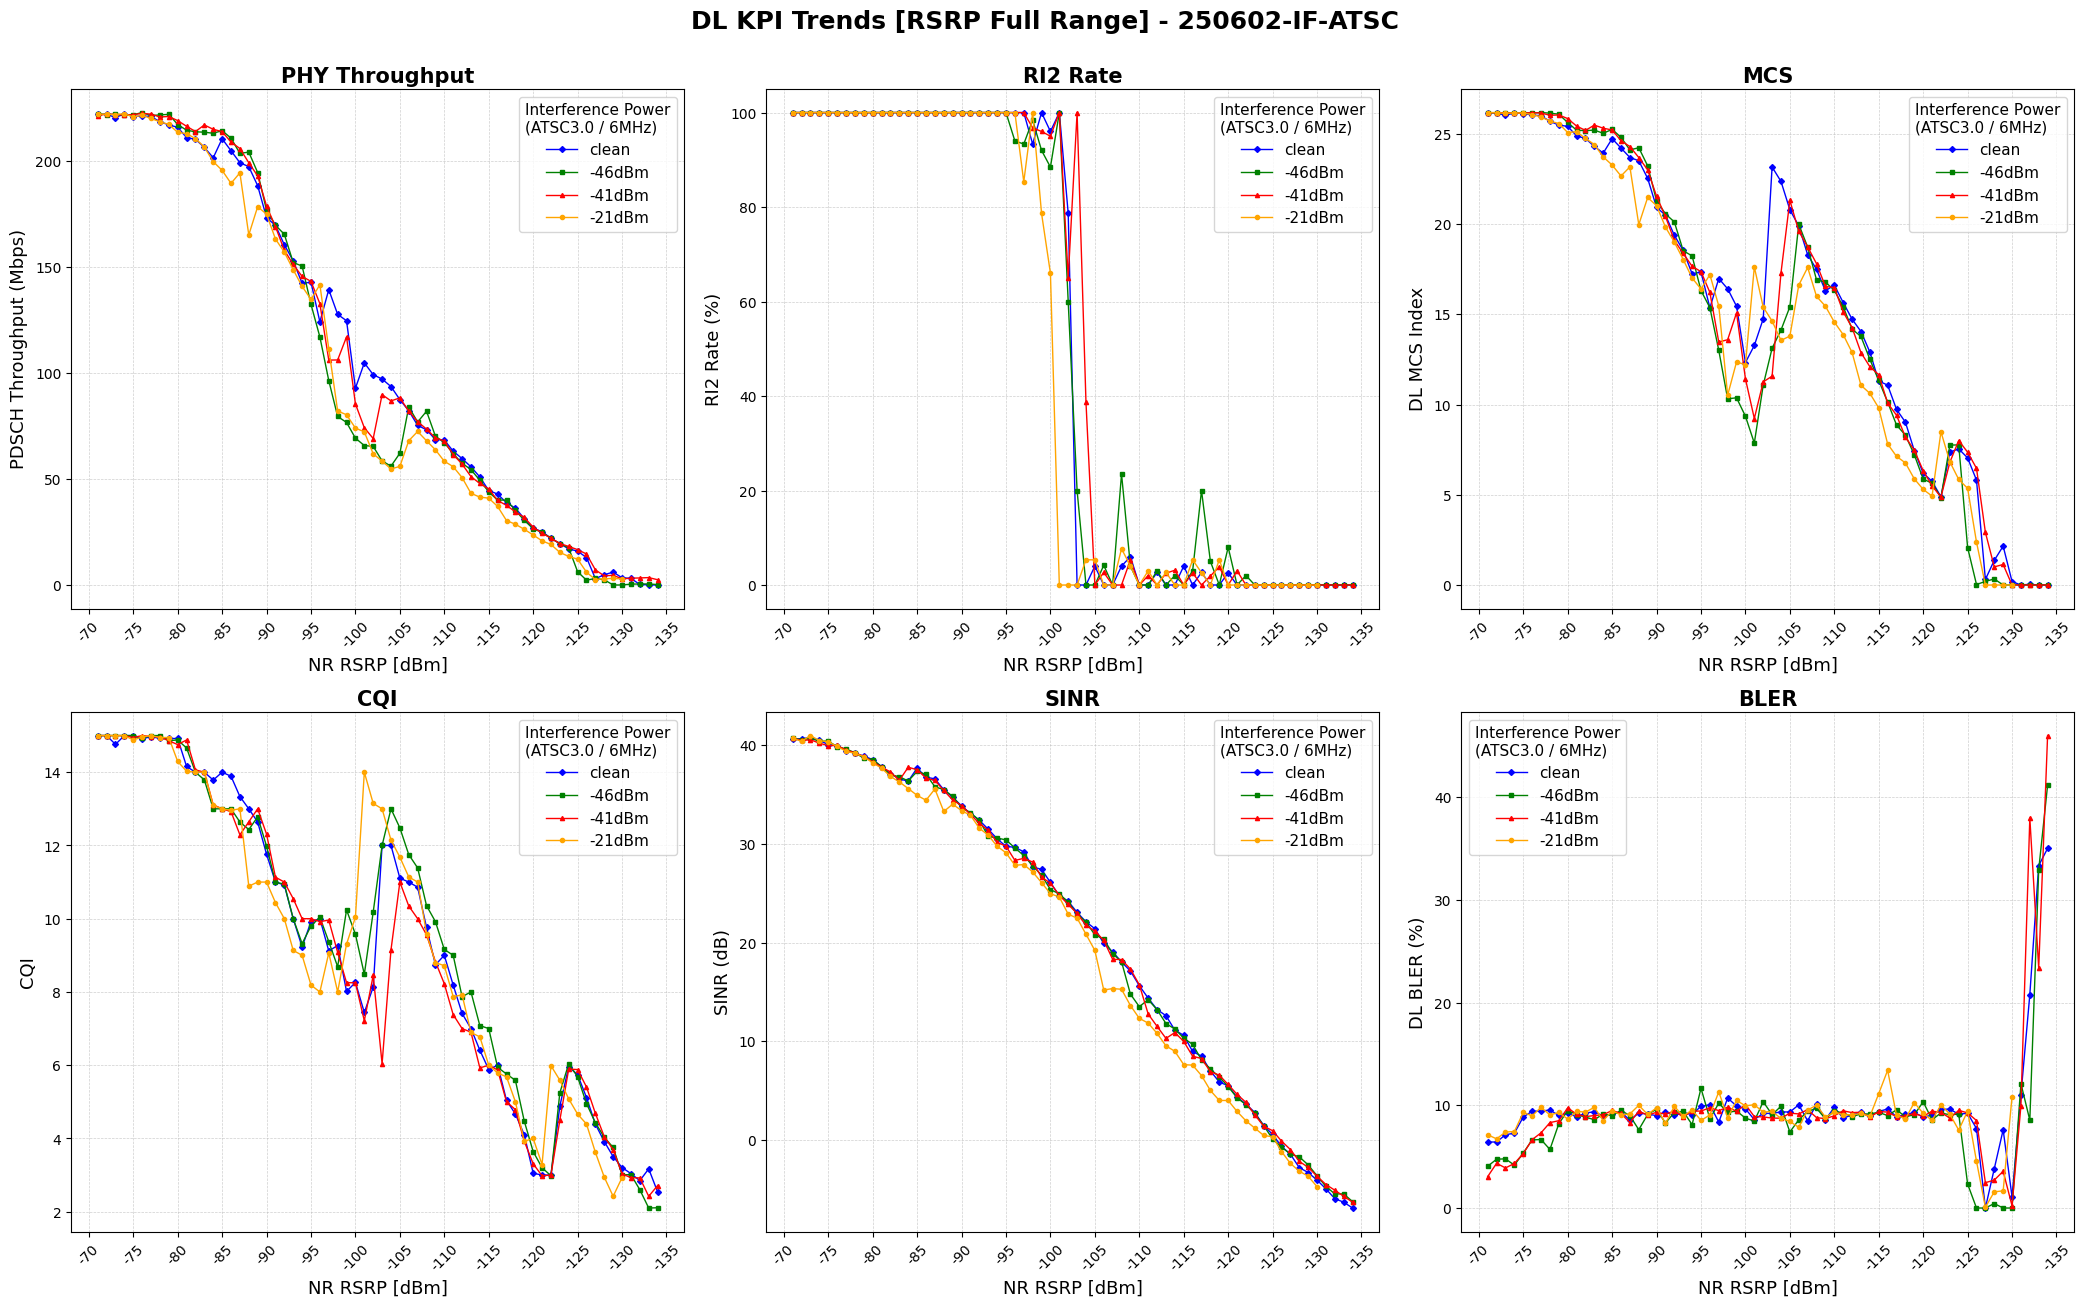

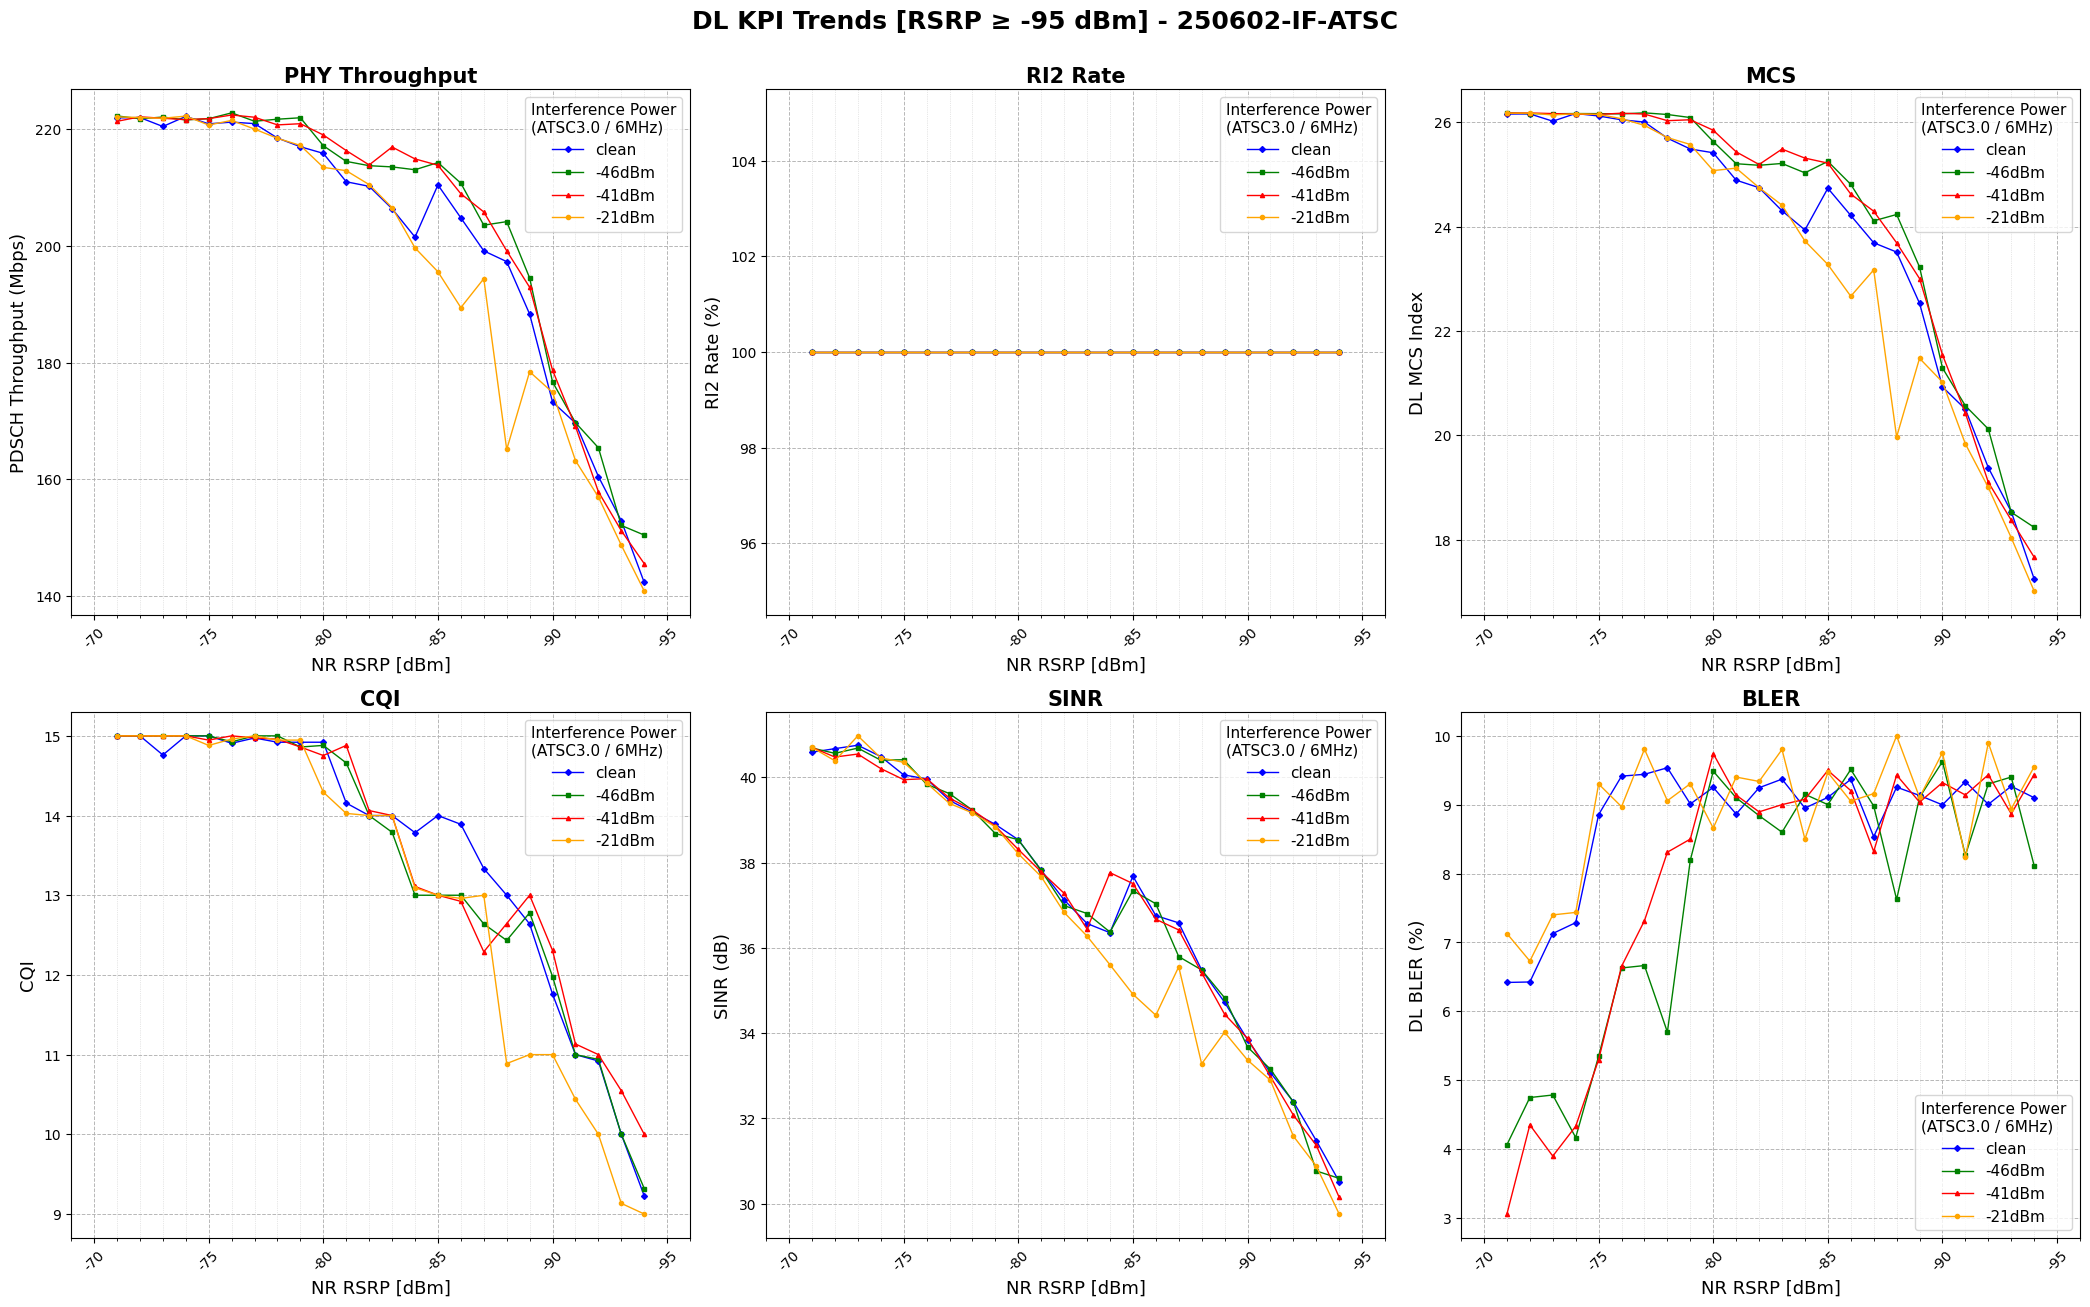

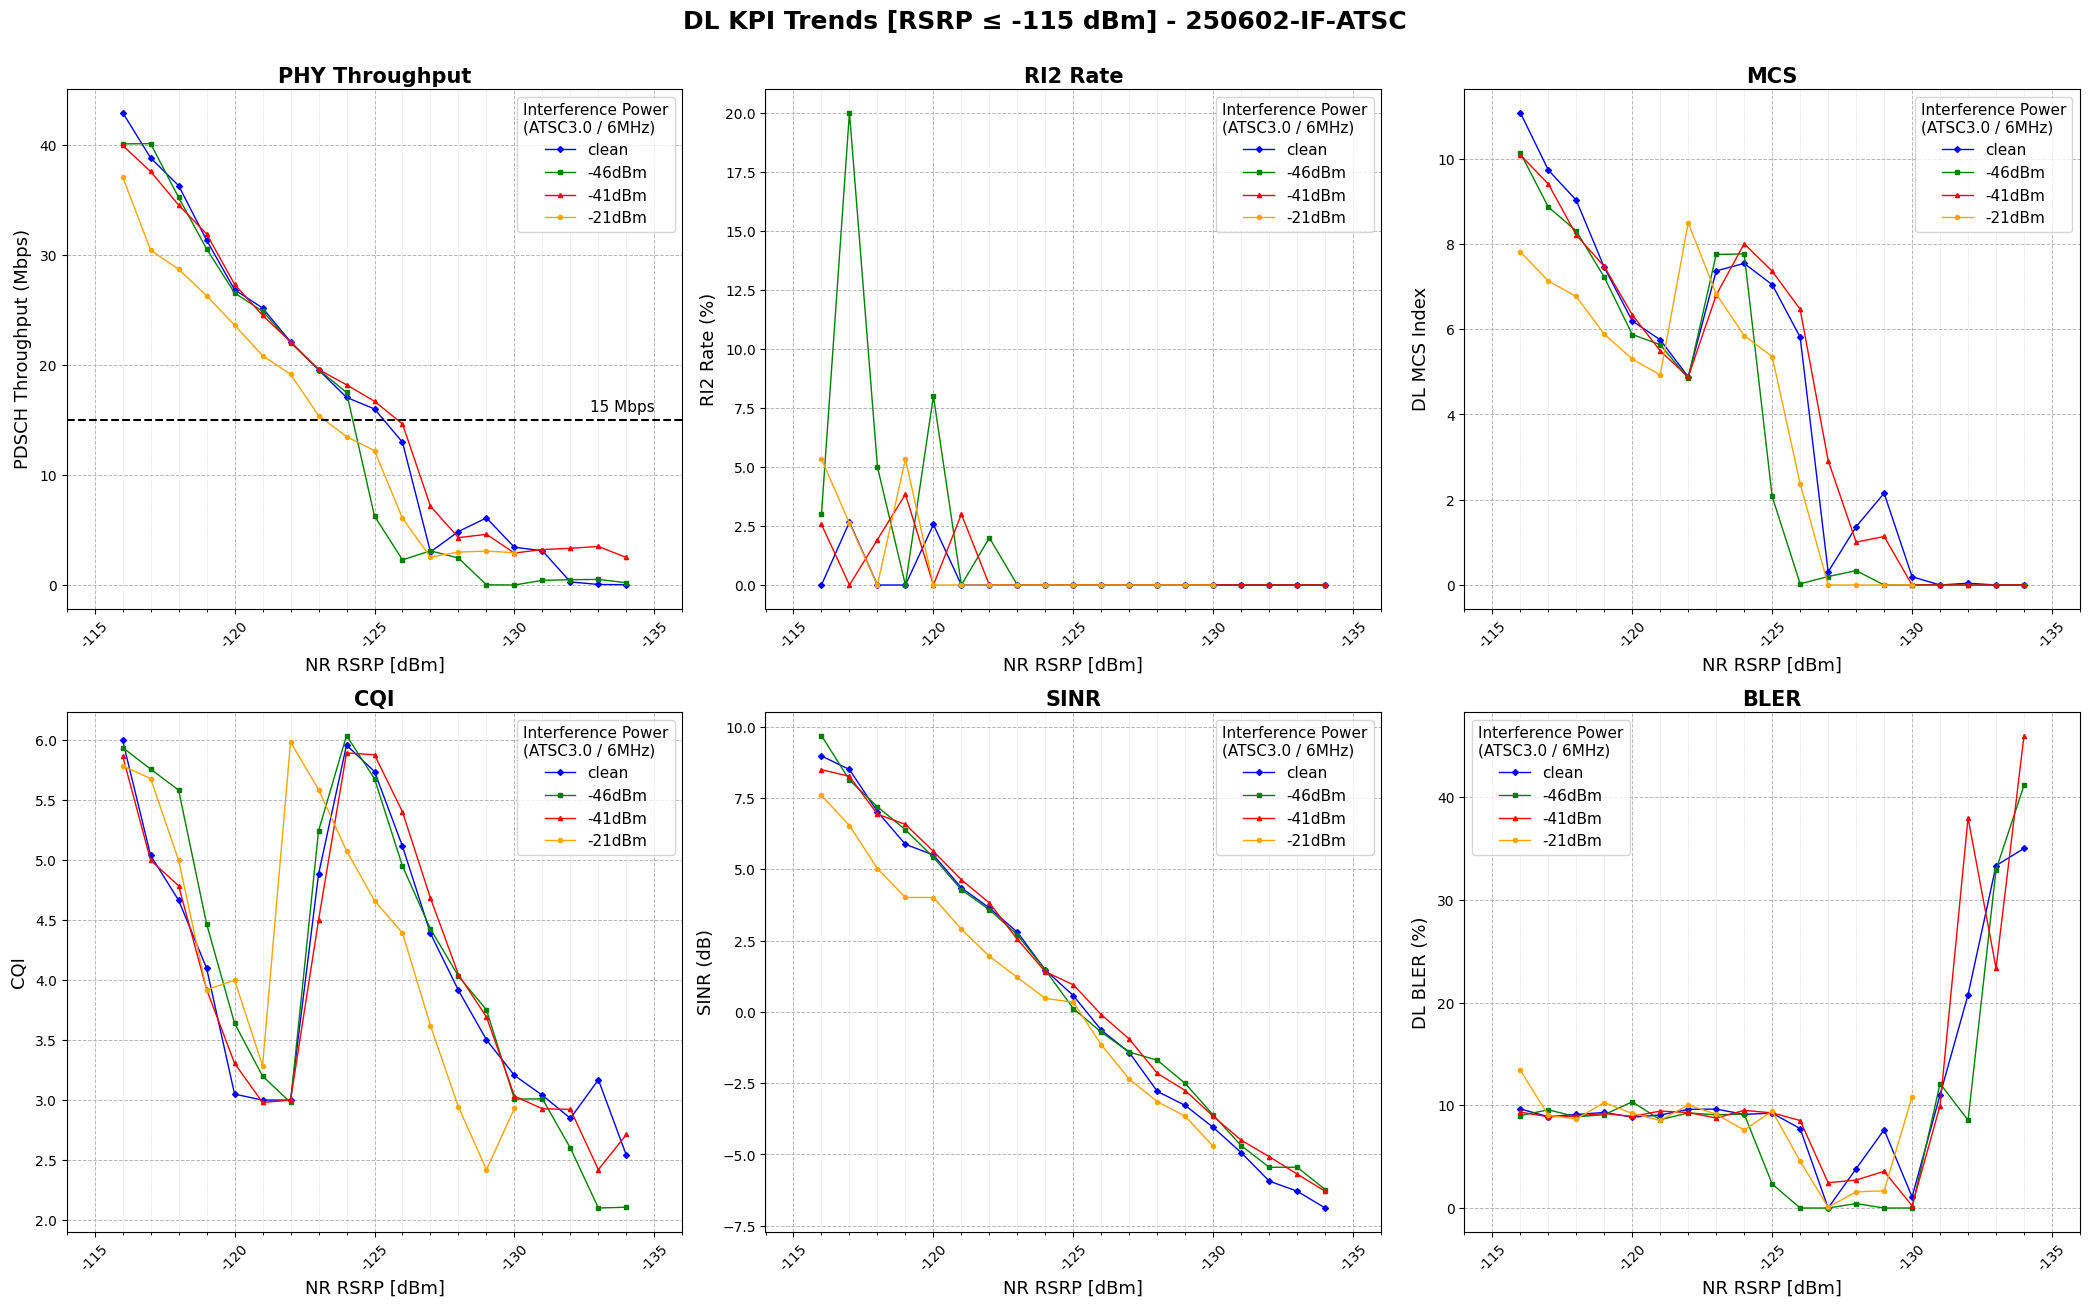

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator, FixedLocator


def plot_kpis_by_rsrp(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='all'):

    df_stacked, source_order = concat_kpi(test_dir=test_dir, bin_size=bin_size)

    plot_config = {
        "DL_Tput[Mbps]": {"ylabel": "PDSCH Throughput (Mbps)", "title": "PHY Throughput"},
        "RI2_Rate[%]": {"ylabel": "RI2 Rate (%)", "title": "RI2 Rate"},
        "DL_MCS": {"ylabel": "DL MCS Index", "title": "MCS"},
        "CQI": {"ylabel": "CQI", "title": "CQI"},
        "SINR[dB]": {"ylabel": "SINR (dB)", "title": "SINR"},
        "DL_BLER[%]": {"ylabel": "DL BLER (%)", "title": "BLER"},
    }

    colors = ['blue','green','red','orange','gray','brown','purple']
    markers = ['D', 's', '^', 'o', '*', 'x', 'P', 'v']
    linestyles = ['-', '--', '-.', ':']

    df_stacked_reset = df_stacked.reset_index()
    rsrp_range = df_stacked_reset["NR_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df_stacked_reset["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    rsrp_start, rsrp_end, offset = -70, -135, 2
    if rsrp_class == 'high':
        rsrp_start, rsrp_end, offset = -70, -95, 1
    elif rsrp_class == 'low':
        rsrp_start, rsrp_end, offset = -115, -135, 1
    
    xtick_labels = list(range(rsrp_start, rsrp_end-1, -5))
    df_filter = df_stacked_reset[(df_stacked_reset["RSRP_Int"] < rsrp_start) & (df_stacked_reset["RSRP_Int"] > rsrp_end)]
    
    n_rows, n_cols = 2, 3
    subplot_width, subplot_height = 7, 6  # 각 서브플롯 크기 (인치 단위)
    figsize = (n_cols * subplot_width, n_rows * subplot_height+1)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.subplots_adjust(hspace=0.8,wspace=0.8)
    axs = axs.flatten()

    for i, (kpi, cfg) in enumerate(plot_config.items()):
        ax = axs[i]
        for j, source in enumerate(source_order):
            subset = df_filter[df_filter["IF_Power"] == source]
            subset = subset.sort_values(by="RSRP_Int", ascending=False)

            ax.plot(
                subset["RSRP_Int"],
                subset[kpi],
                marker=markers[j % len(markers)],
                color=colors[j % len(colors)],
                label=source,
                # linestyle=linestyles[j % len(linestyles)],
                linewidth=1,
                markersize=3
            )

        ax.set_title(cfg["title"], fontsize=15, weight="bold", pad=5)
        ax.set_xlabel("NR RSRP [dBm]", fontsize=13)
        ax.set_ylabel(cfg["ylabel"], fontsize=13, labelpad=5)
        ax.tick_params(axis='x', labelrotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        ax.set_xticks(xtick_labels)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlim(rsrp_start+offset, rsrp_end-offset)
        ax.legend(title=f"Interference Power\n({if_name})", fontsize=11, title_fontsize=11)

        
        if kpi == "DL_Tput[Mbps]":
            if rsrp_class == 'low':
                y_val = 15 # 700M 커버리지 기준 값
                ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
                ax.text(
                    x=ax.get_xlim()[1] + 1,   # x축 오른쪽 끝
                    y=y_val + 0.5,            # y값 약간 위
                    s=f"{y_val} Mbps",        # 표시할 텍스트
                    fontsize=11,
                    color='black',
                    verticalalignment='bottom',
                    horizontalalignment='right'
                )

        if rsrp_class in ['high', 'low']:
            ax.xaxis.set_minor_locator(MultipleLocator(1))  # 1dB 단위 grid
            ax.xaxis.set_major_locator(FixedLocator(xtick_labels))  # 5dB 간격 tick 고정   
            ax.grid(True, which='major', axis='both', linestyle='--', linewidth=0.7, alpha=0.9)
            ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
        else:
            ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.6)

    if rsrp_class == 'all':
        fig.suptitle(f"DL KPI Trends [RSRP Full Range] - {test_dir}", fontsize=18, weight='bold', y=1.002)
    elif rsrp_class == 'high':
        fig.suptitle(f"DL KPI Trends [RSRP ≥ {rsrp_end} dBm] - {test_dir}", fontsize=18, weight='bold', y=1.002)
    elif rsrp_class == 'low':
        fig.suptitle(f"DL KPI Trends [RSRP ≤ {rsrp_start} dBm] - {test_dir}", fontsize=18, weight='bold', y=1.002)

    plt.tight_layout()

    output_path = os.path.join(test_dir, f"rsrp_bin_{bin_size}dB_{rsrp_class}.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.3)

    plt.show()

plot_kpis_by_rsrp(test_dir="250602-IF-ATSC", bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='all')
print()
plot_kpis_by_rsrp(test_dir="250602-IF-ATSC", bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='high')
print()
plot_kpis_by_rsrp(test_dir="250602-IF-ATSC", bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_class='low')

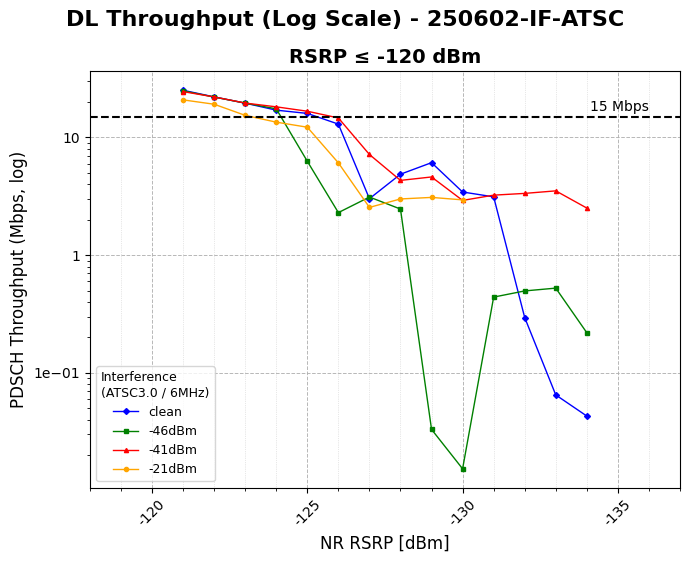

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator, LogFormatter
import os

def plot_tput_logscale_low_rsrp(test_dir, bin_size=1, if_name="ATSC3.0 / 6MHz", rsrp_threshold=-115):
    colors = ['blue','green','red','orange','gray','brown','purple']
    markers = ['D', 's', '^', 'o', '*', 'x', 'P', 'v']

    fig, ax = plt.subplots(figsize=(7, 6))
    df_stacked, source_order = concat_kpi(test_dir=test_dir, bin_size=bin_size)
    df_stacked_reset = df_stacked.reset_index()
    rsrp_range = df_stacked_reset["NR_RSRP[dBm]"].str.replace(" ", "").str.split("~")
    df_stacked_reset["RSRP_Int"] = rsrp_range.apply(lambda x: (int(x[0]) + int(x[1])) // 2)

    # ✅ 입력받은 RSRP threshold 기준으로 구간 설정
    rsrp_start, rsrp_end, offset = rsrp_threshold, -135, 1
    xtick_labels = list(range(rsrp_start, rsrp_end - 1, -5))
    df_filter = df_stacked_reset[
        (df_stacked_reset["RSRP_Int"] < rsrp_start) &
        (df_stacked_reset["RSRP_Int"] > rsrp_end)
    ]

    for j, source in enumerate(source_order):
        subset = df_filter[df_filter["IF_Power"] == source]
        subset = subset.sort_values(by="RSRP_Int", ascending=False)

        ax.plot(
            subset["RSRP_Int"],
            subset["DL_Tput[Mbps]"],
            marker=markers[j % len(markers)],
            color=colors[j % len(colors)],
            label=source,
            linewidth=1,
            markersize=3
        )

    ax.set_title(f"RSRP ≤ {rsrp_threshold} dBm", fontsize=14, weight='bold')
    ax.set_xlabel("NR RSRP [dBm]", fontsize=12)
    ax.set_ylabel("PDSCH Throughput (Mbps, log)", fontsize=12)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(LogFormatter(labelOnlyBase=False))
    ax.tick_params(axis='x', labelrotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    ax.set_xticks(xtick_labels)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlim(rsrp_start + 2, rsrp_end - 2)

    # 기준선 15 Mbps
    y_val = 15
    ax.axhline(y=y_val, color='black', linestyle='--', linewidth=1.5)
    ax.text(
        x=ax.get_xlim()[1] + 1,
        y=y_val * 1.05,
        s=f"{y_val} Mbps",
        fontsize=10,
        color='black',
        va='bottom',
        ha='right'
    )

    # grid
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(FixedLocator(xtick_labels))
    ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.7, alpha=0.9)
    ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.7, alpha=0.9)

    ax.legend(title=f"Interference\n({if_name})", fontsize=9, title_fontsize=9)


    fig.suptitle(f"DL Throughput (Log Scale) - {test_dir}", fontsize=16, weight='bold', y=0.93)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    output_path = os.path.join(test_dir, "rsrp_low_tput_logscale.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.3)

    plt.show()

plot_tput_logscale_low_rsrp(test_dir="250602-IF-ATSC", bin_size=1, rsrp_threshold=-120)